# **1. Intervalo Data**

In [1]:
DATA_INICIO = "2024-03-16"  # Inicio da base de dados
DATA_FIM    = "2025-12-31"

# **2. Importando as Bibliotecas**

In [2]:
import pandas as pd
import numpy as np
from sklearn.ensemble import GradientBoostingClassifier
import warnings
import joblib
import time
import matplotlib.pyplot as plt

# Desativa avisos de cálculos matemáticos irrelevantes
warnings.filterwarnings("ignore")


def drop_reset_index(df):
    """
    Remove valores nulos e reseta o índice começando em 1.
    """
    # Usamos inplace=True para economizar memória em bases grandes
    df = df.dropna().reset_index(drop=True)
    df.index += 1
    return df

def safe_prob(column):
    """
    Transforma Odds em Probabilidades de forma segura, evitando erro de divisão por zero.
    """
    return (1 / column.replace(0, np.nan)).fillna(0)

# **3. CARREGAMENTO E PREPARAÇÃO DA BASE (GitHub)**

In [3]:
# 1. URL da Base de Dados
url = "https://github.com/futpythontrader/Bases_de_Dados/raw/refs/heads/main/Base_de_Dados_BetfairExchange.csv"

# 2. Carregamento e Conversão de Data
# Já convertemos a data no ato da leitura para garantir a ordenação cronológica
Base_de_Dados_Betfair = pd.read_csv(url)
Base_de_Dados_Betfair["Date"] = pd.to_datetime(Base_de_Dados_Betfair["Date"])

# 3. Ordenação (Fundamental para que o shift(1) não use dados do futuro)
Base_de_Dados_Betfair = Base_de_Dados_Betfair.sort_values(["Date", "Home"]).reset_index(drop=True)

# 4. Limpeza e Reset de Índice usando sua função
base = drop_reset_index(Base_de_Dados_Betfair)

print(f"Base carregada e ordenada! Total de registros: {len(base)}")

Base carregada e ordenada! Total de registros: 41203


# **4. Criando, Treinando, Testando e Salvando o Modelo**

In [24]:
# ==========================================================
# 1. CONFIGURAÇÕES E FILTROS INICIAIS
# ==========================================================
decay = 0.980
k = 200
data_primeiro_teste = "2024-07-31"
target_col = "Lay_Away"
RESP = 50
COMISSAO = 0.955
ODD_Max = 4.00
FILTRO_EDGE = 0.09

# Lista de Ligas Lucrativas validada
ligas_lucrativas = [
    "BELGIUM 1", "SWITZERLAND 1", "FRANCE 1", "ITALY 2", "CHILE 1",
    "ENGLAND 2", "CHINA 1", "SPAIN 2", "SOUTH KOREA 2", "SCOTLAND 2",
    "DENMARK 1", "NETHERLANDS 1", "ENGLAND 4", "SLOVAKIA 1", "IRELAND 1"
]

# --- SELECIONANDO AS COLUNAS ---
cols_input = [
    "League", "Date", "Home", "Away", "Goals_H_FT", "Goals_A_FT", "Goals_H_HT", "Goals_A_HT",
    "Odd_H_Back", "Odd_H_Lay", "Odd_D_Back", "Odd_A_Back", "Odd_A_Lay", "Odd_Over25_FT_Back",
    "Odd_BTTS_Yes_Back", "Odd_CS_1x0_Lay", "Odd_CS_2x1_Lay", "Odd_CS_3x1_Lay",
    "Odd_CS_0x0_Lay", "Odd_CS_1x1_Lay", "Min_Goals_H", "Min_Goals_A"
]

# 'base' é o seu dataframe original carregado do CSV
df_base = base[[c for c in cols_input if c in base.columns]].copy()
df_base["Date"] = pd.to_datetime(df_base["Date"])

# ==========================================================
# 2. FEATURE ENGINEERING (UNIFICADO)
# ==========================================================

# A. Alvos (Targets)
df_base["Result"] = np.select(
    [df_base["Goals_H_FT"] > df_base["Goals_A_FT"],
     df_base["Goals_H_FT"] == df_base["Goals_A_FT"],
     df_base["Goals_H_FT"] < df_base["Goals_A_FT"]],
    ["H", "D", "A"], default="NA"
)
df_base["Lay_Away"] = (df_base["Result"] != "A").astype(int)

# B. Variáveis de Mercado
df_base['Prob_1x2_A'] = safe_prob(df_base['Odd_A_Back'])
df_base['Prob_CS_Resistance'] = safe_prob(df_base['Odd_CS_1x0_Lay']) + safe_prob(df_base['Odd_CS_2x1_Lay'])
df_base['Market_Asymmetry'] = (df_base['Prob_CS_Resistance'] - df_base['Prob_1x2_A'])
df_base['Draw_Density'] = safe_prob(df_base['Odd_CS_0x0_Lay']) + safe_prob(df_base['Odd_CS_1x1_Lay'])
df_base['Volatility_Risk'] = np.clip((df_base['Odd_Over25_FT_Back'] / df_base['Odd_A_Back'].replace(0, np.nan)), 0, 50)

# C. Médias Móveis e Tendências
df_base = df_base.sort_values(["Date", "Home"])
df_base['Away_Odd_Trend'] = df_base.groupby('Away')['Odd_A_Back'].transform(lambda x: x.shift(1).rolling(3, min_periods=1).mean() - x.shift(1)).fillna(0)
df_base['Home_HT_Def_Power'] = df_base.groupby('Home')['Goals_A_HT'].transform(lambda x: x.shift(1).rolling(5, min_periods=1).mean()).fillna(0)
df_base['Home_Attack_Strength'] = df_base.groupby('Home')['Goals_H_FT'].transform(lambda x: x.shift(1).rolling(8, min_periods=1).mean()).fillna(0)
df_base['Away_Attack_Strength'] = df_base.groupby('Away')['Goals_A_FT'].transform(lambda x: x.shift(1).rolling(8, min_periods=1).mean()).fillna(0)
df_base['Power_Diff'] = df_base['Home_Attack_Strength'] - df_base['Away_Attack_Strength']

# D. Contexto de Liga
df_base['League_Avg_Goals'] = df_base.groupby('League')['Goals_H_FT'].transform(lambda x: x.shift(1).expanding().mean()).fillna(df_base['Goals_H_FT'].mean())

# E. Late Goal Factor (Calculado ANTES de deletar colunas)
def count_late_goals(goals_str):
    if not isinstance(goals_str, str) or goals_str in ["", "0", "nan"]: return 0
    try: return sum(1 for g in goals_str.split(',') if g.strip().isdigit() and int(g) > 70)
    except: return 0

df_base['temp_late'] = df_base['Min_Goals_H'].apply(count_late_goals)
df_base['Home_Late_Scoring'] = df_base.groupby('Home')['temp_late'].transform(lambda x: x.shift(1).rolling(10, min_periods=1).mean()).fillna(0)

# Limpeza das colunas auxiliares pesadas
df_base.drop(columns=['temp_late', 'Min_Goals_H', 'Min_Goals_A'], inplace=True, errors='ignore')

# ==========================================================
# 3. FILTROS DE ENTRADA (MÉTODO LAY AWAY)
# ==========================================================
df_model = df_base[
    (df_base['League'].isin(ligas_lucrativas)) &
    (df_base['Odd_A_Lay'] <= ODD_Max) &
    (df_base['Odd_H_Back'] < df_base['Odd_A_Back']) &
    (abs(df_base['Odd_A_Back'] - df_base['Odd_A_Lay']) <= 1.00) &
    (abs(df_base['Odd_H_Back'] - df_base['Odd_H_Lay']) <= 1.00)
].copy()

df_model = drop_reset_index(df_model)

# ==========================================================
# 4. WALK-FORWARD E TREINAMENTO
# ================================
X_base = ["Volatility_Risk", "Market_Asymmetry", "League_Avg_Goals", "Draw_Density", "Away_Odd_Trend", "Power_Diff"]

df_model["Previsao"] = np.nan
datas_teste = pd.date_range(start=data_primeiro_teste, end=df_model["Date"].max(), freq="MS")

for data_teste in datas_teste:
    treino = df_model[df_model["Date"] < data_teste].copy()
    teste = df_model[(df_model["Date"] >= data_teste) & (df_model["Date"] < data_teste + pd.DateOffset(months=1))].copy()

    if len(teste) == 0 or len(treino) < 150: continue

    # Decaimento temporal nos pesos do treino
    treino["peso"] = decay ** (data_teste - treino["Date"]).dt.days
    media_global = np.average(treino[target_col], weights=treino["peso"])

    # Credibilidade das Ligas (LIGA_RATE)
    l_stats = treino.groupby("League").apply(lambda x: pd.Series({
        "m": np.average(x[target_col], weights=x["peso"]),
        "n": x["peso"].sum()
    }), include_groups=False)

    l_stats["LIGA_RATE"] = ((l_stats["n"] * l_stats["m"] + k * media_global) / (l_stats["n"] + k))

    treino["LIGA_RATE"] = treino["League"].map(l_stats["LIGA_RATE"]).fillna(media_global)
    teste["LIGA_RATE"] = teste["League"].map(l_stats["LIGA_RATE"]).fillna(media_global)

    # Gradient Boosting
    clf = GradientBoostingClassifier(n_estimators=450, learning_rate=0.015, max_depth=3, random_state=42)
    clf.fit(treino[X_base + ["LIGA_RATE"]], treino[target_col].astype(int))

    df_model.loc[teste.index, "Previsao"] = clf.predict_proba(teste[X_base + ["LIGA_RATE"]])[:, 1]

# ==========================================================
# 5. ANÁLISE DE RESULTADOS
# ==========================================================
df_final = df_model.dropna(subset=['Previsao']).copy()
df_final["Edge"] = df_final["Previsao"] - (1 - (1 / df_final["Odd_A_Lay"]))

df_punter = df_final[df_final["Edge"] > FILTRO_EDGE].copy()

if not df_punter.empty:
    df_punter['Profit'] = np.where(df_punter['Result'] != 'A',
                                   (RESP / (df_punter['Odd_A_Lay'] - 1)) * COMISSAO,
                                   -RESP)
    roi_real = (df_punter['Profit'].sum() / (len(df_punter) * RESP)) * 100

    print("-" * 40)
    print(f"📊 RESULTADOS FINAIS (Ligas Selecionadas)")
    print(f"ROI REAL: {roi_real:.2f}%")
    print(f"Total Operações: {len(df_punter)}")
    print(f"Win Rate: {(df_punter['Profit'] > 0).mean():.2%}")
    print("-" * 40)
else:
    print("Nenhuma operação encontrada com os filtros atuais.")

df_punter = drop_reset_index(df_punter)

----------------------------------------
📊 RESULTADOS FINAIS (Ligas Selecionadas)
ROI REAL: 8.41%
Total Operações: 409
Win Rate: 76.53%
----------------------------------------


# **5. TREINO FINAL E EXPORTAÇÃO**

In [5]:
# 1. Preparando os dados finais (Toda a base que passou pelo filtro)
df_final_treino = df_model.copy()

# 2. Calculando o LIGA_RATE final para o Scanner usar
dias_diff_final = (df_final_treino["Date"].max() - df_final_treino["Date"]).dt.days
df_final_treino["peso"] = decay ** dias_diff_final
media_global_final = np.average(df_final_treino[target_col], weights=df_final_treino["peso"])

l_stats_final = df_final_treino.groupby("League").apply(lambda x: pd.Series({
    "m": np.average(x[target_col], weights=x["peso"]),
    "n": x["peso"].sum()
}), include_groups=False)

l_stats_final["LIGA_RATE"] = ((l_stats_final["n"] * l_stats_final["m"] + k * media_global_final) / (l_stats_final["n"] + k))

# Aplicando o LIGA_RATE na base de treino final
df_final_treino["LIGA_RATE"] = df_final_treino["League"].map(l_stats_final["LIGA_RATE"]).fillna(media_global_final)

# 3. Treinando o Classificador Final (Cérebro do Robô)
X_final_cols = X_base + ["LIGA_RATE"]
clf_final = GradientBoostingClassifier(n_estimators=450, learning_rate=0.015, max_depth=3, random_state=42)
clf_final.fit(df_final_treino[X_final_cols], df_final_treino[target_col].astype(int))

# 4. Salvando o Combo (Modelo + Taxas de Ligas)
modelo_completo = {
    "modelo": clf_final,
    "features": X_final_cols,
    "liga_rates": l_stats_final["LIGA_RATE"].to_dict(),
    "media_global": media_global_final,
    "ligas_autorizadas": ligas_lucrativas # Salva as ligas que você filtrou
}

joblib.dump(modelo_completo, 'Modelo_LayAway_5.pkl')

print("\n" + "="*40)
print("🚀 ARQUIVO PRONTO PARA O SCANNER!")
print("O arquivo 'Modelo_LayAway_5.pkl' foi gerado.")
print("Ele contém o modelo treinado e os pesos de cada liga.")
print("="*40)


🚀 ARQUIVO PRONTO PARA O SCANNER!
O arquivo 'Modelo_LayAway_5.pkl' foi gerado.
Ele contém o modelo treinado e os pesos de cada liga.


# **Extra 1. Melhores variáveis e agrupamento de ligas lucrativas**

In [6]:
# import seaborn as sns

# # Extrair a importância das variáveis do último modelo treinado no loop
# importances = model.feature_importances_
# feature_names = X_base + ["LIGA_RATE"]
# feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
# feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# # Plotar
# plt.figure(figsize=(10, 6))
# sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')
# plt.title('Raio-X do Modelo: O que ele mais considera?')
# plt.show()

# print(feature_importance_df)

In [7]:
# # Agrupando por Liga para ver onde o dinheiro está fugindo
# league_performance = df_punter.groupby('League').agg({
#     'Profit': 'sum',
#     'Result': 'count',
#     'Lay_Away': 'mean' # Taxa de acerto por liga
# }).rename(columns={'Result': 'Ops', 'Lay_Away': 'WinRate'})

# # Calcular ROI por Liga
# league_performance['ROI'] = (league_performance['Profit'] / (league_performance['Ops'] * RESP)) * 100

# # Top 10 Melhores
# print("--- TOP 40 LIGAS LUCRATIVAS ---")
# print(league_performance.sort_values(by='Profit', ascending=False).head(40))

# print("\n--- TOP 40 LIGAS PREJUÍZO (PARA EXCLUIR) ---")
# print(league_performance.sort_values(by='Profit', ascending=True).head(40))

# **6. Cálculo das Métricas**

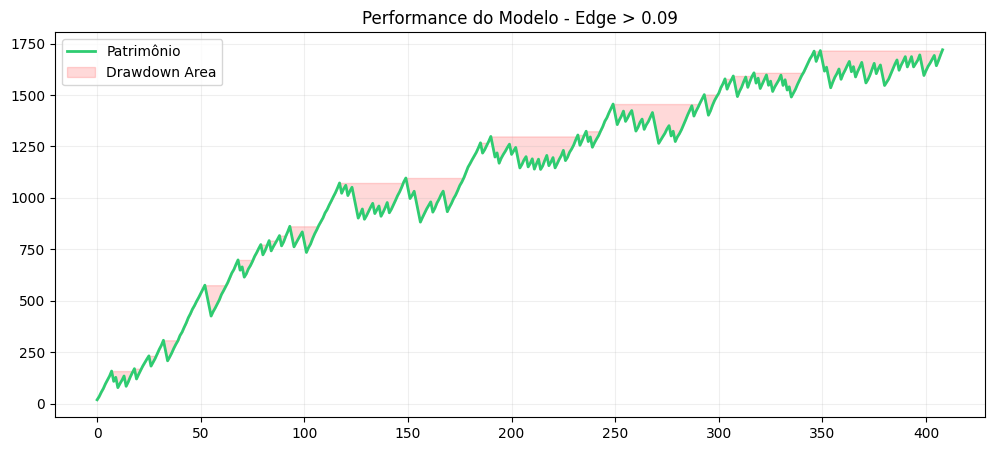

--- RELATÓRIO DE RISCO E SOBREVIVÊNCIA ---
Total de Entradas: 409
Taxa de Acerto: 76.53%
Média de Green: R$ 20.83
Média de Red:   R$ -50.00
Profit Total: R$ 1720.29
ROI por Operação: 8.41%
ROI Final sobre Banca: 114.69%
----------------------------------------
⭐ RELAÇÃO GREEN/RED: Precisa de 2.40 Greens para pagar 1 Red
⭐ DURAÇÃO DA QUEDA (MAX DD): 7 jogos seguidos abaixo do topo
----------------------------------------
Fator de Recuperação (Profit/DD): 8.02
Drawdown Máximo: R$ -214.59
Risco de Ruína Teórico: 0.0000%


In [25]:
# 1. Configurações de Simulação
FILTRO_EDGE = 0.09
BANCA_INICIAL = 1500
RESPONSABILIDADE = 50
COMISSAO = 0.955

# 2. Filtragem e Preparação
if 'df_punter' in locals() and len(df_punter) > 0:
    df = df_punter[df_punter["Edge"] > FILTRO_EDGE].copy()
    df = df.sort_values("Date").reset_index(drop=True)
else:
    df = pd.DataFrame()

if len(df) == 0:
    print("⚠️ Nenhuma entrada encontrada.")
else:
    # --- Cálculos de Profit (Lógica Lay Away) ---
    df['Profit'] = np.where(
        df['Result'] != 'A',
        (RESPONSABILIDADE / (df['Odd_A_Lay'] - 1)) * COMISSAO,
        -RESPONSABILIDADE
    )

    df['Profit_acu'] = df['Profit'].cumsum()
    df['Max_acu'] = df['Profit_acu'].cummax()
    df['DrawDown'] = df['Profit_acu'] - df['Max_acu']

    # --- Estatísticas de Performance ---
    total_jogos = len(df)
    total_acertos = (df['Result'] != 'A').sum()
    win_rate = total_acertos / total_jogos

    profit_final = df['Profit_acu'].iloc[-1]
    greens = df[df['Profit'] > 0]['Profit']
    reds = df[df['Profit'] < 0]['Profit']

    media_green = greens.mean() if len(greens) > 0 else 0
    media_red = abs(reds.mean()) if len(reds) > 0 else 1

    # 1) RELAÇÃO GREEN / RED (Quantos greens pagam 1 red)
    # No Lay, como o red é fixo (responsabilidade), dividimos o Red pelo Green médio
    razao_pagamento = media_red / media_green if media_green > 0 else np.inf

    # 2) DURAÇÃO DA QUEDA NO MAX DD
    max_drawdown = df['DrawDown'].min()
    idx_dd_max = df['DrawDown'].idxmin()
    # Localizar o topo (All-Time High) antes do mergulho no Max DD
    idx_topo = df.loc[:idx_dd_max][df['Profit_acu'] == df.loc[idx_dd_max, 'Max_acu']].index.max()
    duracao_queda = idx_dd_max - idx_topo

    # --- Risco de Ruína e ROI ---
    fr = abs(profit_final / max_drawdown) if max_drawdown != 0 else np.inf
    roi_banca = (profit_final / BANCA_INICIAL) * 100
    roi_entrada = (profit_final / (total_jogos * RESPONSABILIDADE)) * 100

    p = 1 - win_rate
    q = win_rate
    risco_ruina = ((p / q) ** (BANCA_INICIAL / RESPONSABILIDADE)) * 100 if q > p else 100.0

    # --- Visualização ---
    plt.figure(figsize=(12, 5))
    df['Profit_acu'].plot(color='#2ecc71', linewidth=2, label='Patrimônio')
    plt.fill_between(range(len(df)), df['Profit_acu'], df['Max_acu'], color='red', alpha=0.15, label='Drawdown Area')
    plt.title(f'Performance do Modelo - Edge > {FILTRO_EDGE}')
    plt.legend()
    plt.grid(True, alpha=0.2)
    plt.show()

    # --- Relatório de Riscos ---
    print(f"--- RELATÓRIO DE RISCO E SOBREVIVÊNCIA ---")
    print(f"Total de Entradas: {total_jogos}")
    print(f"Taxa de Acerto: {win_rate:.2%}")
    print(f"Média de Green: R$ {media_green:.2f}")
    print(f"Média de Red:   R$ -{media_red:.2f}")
    print(f"Profit Total: R$ {profit_final:.2f}")
    print(f"ROI por Operação: {roi_entrada:.2f}%")
    print(f"ROI Final sobre Banca: {roi_banca:.2f}%")
    print("-" * 40)
    print(f"⭐ RELAÇÃO GREEN/RED: Precisa de {razao_pagamento:.2f} Greens para pagar 1 Red")
    print(f"⭐ DURAÇÃO DA QUEDA (MAX DD): {duracao_queda} jogos seguidos abaixo do topo")
    print("-" * 40)
    print(f"Fator de Recuperação (Profit/DD): {fr:.2f}")
    print(f"Drawdown Máximo: R$ {max_drawdown:.2f}")
    print(f"Risco de Ruína Teórico: {risco_ruina:.4f}%")


In [26]:
# df_calc.to_excel(f'Entradas_Filtradas.xlsx', index=False)

# **Extra 2. Otimização de Hiperparâmetros (Grid Search) e Validação**

In [10]:
# import itertools
# import pandas as pd
# import numpy as np
# from sklearn.ensemble import GradientBoostingClassifier
# from scipy.stats import randint, uniform
# import warnings
# import time

# warnings.filterwarnings("ignore")

# # ================================
# # 1. FUNÇÕES AUXILIARES
# # ================================
# def safe_prob(column):
#     return (1 / column.replace(0, np.nan)).fillna(0)

# def drop_reset_index(df):
#     return df.dropna().reset_index(drop=True)

# # ================================
# # 2. FEATURE ENGINEERING (FIXA)
# # ================================
# # Supondo que 'base' já esteja carregado
# df_base_prep = base.copy()
# df_base_prep["Date"] = pd.to_datetime(df_base_prep["Date"])
# df_base_prep = df_base_prep.sort_values(["Date", "Home"]).reset_index(drop=True)

# df_base_prep["Result"] = np.select(
#     [df_base_prep["Goals_H_FT"] > df_base_prep["Goals_A_FT"],
#      df_base_prep["Goals_H_FT"] == df_base_prep["Goals_A_FT"],
#      df_base_prep["Goals_H_FT"] < df_base_prep["Goals_A_FT"]],
#     ["H", "D", "A"], default="NA"
# )
# df_base_prep["Lay_Away"] = (df_base_prep["Result"] != "A").astype(int)

# df_base_prep['Prob_1x2_A'] = safe_prob(df_base_prep['Odd_A_Back'])
# df_base_prep['Prob_CS_Resistance'] = safe_prob(df_base_prep['Odd_CS_1x0_Lay']) + safe_prob(df_base_prep['Odd_CS_2x1_Lay'])
# df_base_prep['Market_Asymmetry'] = (df_base_prep['Prob_CS_Resistance'] - df_base_prep['Prob_1x2_A'])
# df_base_prep['Draw_Density'] = safe_prob(df_base_prep['Odd_CS_0x0_Lay']) + safe_prob(df_base_prep['Odd_CS_1x1_Lay'])
# df_base_prep['Volatility_Risk'] = np.clip((df_base_prep['Odd_Over25_FT_Back'] / df_base_prep['Odd_A_Back'].replace(0, np.nan)), 0, 50)
# df_base_prep['Away_Odd_Trend'] = df_base_prep.groupby('Away')['Odd_A_Back'].transform(lambda x: x.shift(1).rolling(3, min_periods=1).mean() - x.shift(1).iloc[-1] if len(x) > 1 else 0).fillna(0)
# df_base_prep['Home_HT_Def_Power'] = df_base_prep.groupby('Home')['Goals_A_HT'].transform(lambda x: x.shift(1).rolling(5, min_periods=1).mean()).fillna(0)
# df_base_prep['Home_Attack_Strength'] = df_base_prep.groupby('Home')['Goals_H_FT'].transform(lambda x: x.shift(1).rolling(8, min_periods=1).mean()).fillna(0)
# df_base_prep['Away_Attack_Strength'] = df_base_prep.groupby('Away')['Goals_A_FT'].transform(lambda x: x.shift(1).rolling(8, min_periods=1).mean()).fillna(0)
# df_base_prep['League_Avg_Goals'] = df_base_prep.groupby('League')['Goals_H_FT'].transform(lambda x: x.shift(1).expanding().mean()).fillna(df_base_prep['Goals_H_FT'].mean())
# df_base_prep['Power_Diff'] = df_base_prep['Home_Attack_Strength'] - df_base_prep['Away_Attack_Strength']

# ligas_lucrativas = ["BELGIUM 1", "SWITZERLAND 1", "FRANCE 1", "ITALY 2", "CHILE 1", "ENGLAND 2", "CHINA 1", "SPAIN 2", "SOUTH KOREA 2", "SCOTLAND 2", "DENMARK 1", "NETHERLANDS 1", "ENGLAND 4", "SLOVAKIA 1", "IRELAND 1"]
# df_base_prep = df_base_prep[df_base_prep['League'].isin(ligas_lucrativas)].reset_index(drop=True)

# # ================================
# # 3. CONFIGURAÇÃO DA OTIMIZAÇÃO
# # ================================
# grids_negocio = {
#     'decay': [0.980, 0.990],
#     'k': [200, 300, 400],
#     'odd_max': [4.0, 5.0],
#     'edge': [0.05, 0.09]
# }

# X_base = ["Volatility_Risk", "Market_Asymmetry", "League_Avg_Goals", "Draw_Density", "Away_Odd_Trend", "Power_Diff"]
# target_col = "Lay_Away"
# combinacoes = list(itertools.product(*grids_negocio.values()))
# n_tentativas_modelo = 5 # Quantidade de modelos aleatórios por combinação de negócio
# resultados_otimizacao = []

# print(f"Iniciando otimização: {len(combinacoes) * n_tentativas_modelo} combinações totais.")

# #
# # ================================
# # 4. LOOP DE OTIMIZAÇÃO
# # ================================
# inicio = time.time()
# contador = 0

# for (d, k_val, o_max, e_min) in combinacoes:
#     for _ in range(n_tentativas_modelo):
#         contador += 1

#         # Sorteando hiperparâmetros do modelo
#         n_est = randint(100, 1000).rvs()
#         l_rate = uniform(0.01, 0.2).rvs()
#         m_depth = randint(3, 10).rvs()
#         sub = [0.8, 0.9, 1.0][np.random.randint(0, 3)]

#         if contador % 10 == 0:
#             tempo_decorrido = (time.time() - inicio) / 60
#             print(f"Processando {contador}/{len(combinacoes) * n_tentativas_modelo}... Decorrido: {tempo_decorrido:.1f} min")

#         df_model = df_base_prep[df_base_prep['Odd_A_Lay'] <= o_max].copy()
#         df_model = df_model[df_model['Odd_H_Back'] < df_model['Odd_A_Back']].reset_index(drop=True)

#         if len(df_model) < 200: continue

#         df_model["Previsao"] = np.nan
#         datas_teste = pd.date_range(start="2024-07-31", end=df_model["Date"].max(), freq="MS")

#         for data_teste in datas_teste:
#             treino = df_model[df_model["Date"] < data_teste].copy()
#             teste = df_model[(df_model["Date"] >= data_teste) & (df_model["Date"] < data_teste + pd.DateOffset(months=1))].copy()

#             if len(teste) == 0 or len(treino) < 150: continue

#             dias_diff = (data_teste - treino["Date"]).dt.days
#             treino["peso"] = d ** dias_diff
#             media_global = np.average(treino[target_col], weights=treino["peso"])

#             def calc_liga(x):
#                 return pd.Series({"m": np.average(x[target_col], weights=x["peso"]), "n": x["peso"].sum()})

#             liga_stats = treino.groupby("League").apply(calc_liga)
#             liga_stats["LIGA_RATE"] = ((liga_stats["n"] * liga_stats["m"] + k_val * media_global) / (liga_stats["n"] + k_val))

#             treino["LIGA_RATE"] = treino["League"].map(liga_stats["LIGA_RATE"]).fillna(media_global)
#             teste["LIGA_RATE"] = teste["League"].map(liga_stats["LIGA_RATE"]).fillna(media_global)

#             model = GradientBoostingClassifier(n_estimators=n_est, learning_rate=l_rate, max_depth=m_depth, subsample=sub, random_state=42)
#             model.fit(treino[X_base + ["LIGA_RATE"]], treino[target_col].astype(int))
#             df_model.loc[teste.index, "Previsao"] = model.predict_proba(teste[X_base + ["LIGA_RATE"]])[:, 1]

#         df_final = df_model.dropna(subset=['Previsao']).copy()
#         df_final["Edge"] = df_final["Previsao"] - (1 - (1 / df_final["Odd_A_Lay"]))
#         df_punter = df_final[df_final["Edge"] > e_min].copy()

#         if len(df_punter) > 50:
#             RESP, COMISSAO = 50, 0.955
#             df_punter['Profit'] = np.where(df_punter['Result'] != 'A', (RESP / (df_punter['Odd_A_Lay'] - 1)) * COMISSAO, -RESP)
#             roi = (df_punter['Profit'].sum() / (len(df_punter) * RESP)) * 100

#             resultados_otimizacao.append({
#                 'Decay': d, 'K': k_val, 'OddMax': o_max, 'Edge': e_min,
#                 'n_est': n_est, 'LR': round(l_rate, 4), 'Depth': m_depth,
#                 'ROI': round(roi, 2), 'Ops': len(df_punter)
#             })

# # ================================
# # 5. RANKING FINAL
# # ================================
# df_results = pd.DataFrame(resultados_otimizacao)
# tempo_total = (time.time() - inicio) / 60
# print(f"\nOtimização Concluída em {tempo_total:.1f} minutos!")
# print("\n--- TOP 30 CONFIGURAÇÕES POR ROI ---")
# print(df_results.sort_values(by='ROI', ascending=False).head(30))

In [11]:
# # ==============================================================
# # SETUP FINAL VALIDADO: CONFIGURAÇÃO 137
# # ==============================================================
# d_final = 0.980
# k_final = 200
# odd_max_final = 4.0
# edge_min_final = 0.09

# # 1. Aplicar Filtros de Entrada
# df_setup = df[df['Odd_A_Lay'] <= odd_max_final].copy()
# df_setup = df_setup[df_setup['Odd_H_Back'] < df_setup['Odd_A_Back']].reset_index(drop=True)

# # 2. Rodar o Walk-Forward Final (Processamento Rápido)
# df_setup["Previsao"] = np.nan
# for data_teste in pd.date_range(start="2024-07-31", end=df_setup["Date"].max(), freq="MS"):
#     treino = df_setup[df_setup["Date"] < data_teste].copy()
#     teste = df_setup[(df_setup["Date"] >= data_teste) & (df_setup["Date"] < data_teste + pd.DateOffset(months=1))].copy()
#     if len(teste) == 0 or len(treino) < 150: continue

#     # Pesos e Liga Rate
#     dias_diff = (data_teste - treino["Date"]).dt.days
#     treino["peso"] = d_final ** dias_diff
#     media_g = np.average(treino["Lay_Away"], weights=treino["peso"])
#     l_stats = treino.groupby("League").apply(lambda x: pd.Series({"m": np.average(x["Lay_Away"], weights=x["peso"]), "n": x["peso"].sum()}))
#     l_stats["LIGA_RATE"] = ((l_stats["n"] * l_stats["m"] + k_final * media_g) / (l_stats["n"] + k_final))

#     treino["LIGA_RATE"] = treino["League"].map(l_stats["LIGA_RATE"]).fillna(media_g)
#     teste["LIGA_RATE"] = teste["League"].map(l_stats["LIGA_RATE"]).fillna(media_g)

#     model = GradientBoostingClassifier(n_estimators=100, learning_rate=0.05, max_depth=3, random_state=42)
#     model.fit(treino[X_base + ["LIGA_RATE"]], treino["Lay_Away"].astype(int))
#     df_setup.loc[teste.index, "Previsao"] = model.predict_proba(teste[X_base + ["LIGA_RATE"]])[:, 1]

# # 3. Análise de Performance Mensal
# df_final = df_setup.dropna(subset=['Previsao']).copy()
# df_final["Edge"] = df_final["Previsao"] - (1 - (1 / df_final["Odd_A_Lay"]))
# df_operacoes = df_final[df_final["Edge"] > edge_min_final].copy()

# RESP = 50
# COMISSAO = 0.955
# df_operacoes['Profit'] = np.where(df_operacoes['Result'] != 'A', (RESP / (df_operacoes['Odd_A_Lay'] - 1)) * COMISSAO, -RESP)
# df_operacoes['Profit_acu'] = df_operacoes['Profit'].cumsum()

# # Gráficos
# import matplotlib.pyplot as plt
# plt.figure(figsize=(12, 5))
# df_operacoes.set_index('Date')['Profit_acu'].plot(title='Equity Curve - Setup 137 (Otimizado)', color='green')
# plt.grid(True)
# plt.show()

# print("\n--- PERFORMANCE MENSAL ---")
# print(df_operacoes.groupby(df_operacoes['Date'].dt.to_period('M'))['Profit'].sum())

# **7. Cálculo de métricas mensais**

In [12]:
# ==============================================================
# RELATÓRIO DE EVOLUÇÃO MENSAL E SAÚDE DA BANCA
# ==============================================================

# 1. Preparação dos Dados Temporais
df_resumo = df.copy()
df_resumo['Date'] = pd.to_datetime(df_resumo['Date'])
df_resumo = df_resumo.sort_values('Date').reset_index(drop=True)
df_resumo['AnoMes'] = df_resumo['Date'].dt.to_period('M')

# 2. Agrupamentos
entradas_por_mes = df_resumo.groupby('AnoMes').size()
lucro_por_mes = df_resumo.groupby('AnoMes')['Profit'].sum()

# Contar acertos (Resultados onde o visitante não venceu)
acertos_por_mes = df_resumo[df_resumo['Result'] != 'A'].groupby('AnoMes').size()
# Garantir que todos os meses do índice apareçam, mesmo com 0 acertos
acertos_por_mes = acertos_por_mes.reindex(entradas_por_mes.index, fill_value=0)

# 3. Cálculos de Performance
assertividade_por_mes = (acertos_por_mes / entradas_por_mes * 100).round(2)
lucro_acumulado = lucro_por_mes.cumsum().round(2)
banca_final_mes = (BANCA_INICIAL + lucro_acumulado).round(2)

# ROI sobre a Banca (Quanto o capital cresceu naquele mês especificamente)
roi_sobre_banca = (lucro_por_mes / BANCA_INICIAL * 100).round(2)

# 4. Montagem do DataFrame de Exibição
resumo = pd.DataFrame({
    'Entradas': entradas_por_mes.values,
    'Win Rate (%)': assertividade_por_mes.map(lambda x: f'{x:.2f}%'),
    'Lucro (R$)': lucro_por_mes.map(lambda x: f'R$ {x:.2f}'),
    'Cresc. Banca (%)': roi_sobre_banca.map(lambda x: f'{x:.2f}%'),
    'Lucro Acum.': lucro_acumulado.map(lambda x: f'R$ {x:.2f}'),
    'Banca Final': banca_final_mes.map(lambda x: f'R$ {x:.2f}')
}, index=lucro_por_mes.index.astype(str))

# 5. Estilização e Exibição
print("\n" + "="*50)
print("             EXTRATO MENSAL DE PERFORMANCE")
print("="*50)
display(resumo)


             EXTRATO MENSAL DE PERFORMANCE


,Entradas,Win Rate (%),Lucro (R$),Cresc. Banca (%),Lucro Acum.,Banca Final
AnoMes,,,,,,
2024-08,41,82.93%,R$ 330.99,22.07%,R$ 330.99,R$ 1830.99
2024-09,37,86.49%,R$ 402.81,26.85%,R$ 733.80,R$ 2233.80
2024-10,47,78.72%,R$ 268.06,17.87%,R$ 1001.86,R$ 2501.86
2024-11,29,72.41%,R$ 30.47,2.03%,R$ 1032.33,R$ 2532.33
2024-12,29,79.31%,R$ 171.44,11.43%,R$ 1203.76,R$ 2703.76
2025-01,31,70.97%,R$ -15.35,-1.02%,R$ 1188.41,R$ 2688.41
2025-02,30,76.67%,R$ 137.36,9.16%,R$ 1325.77,R$ 2825.77
2025-03,34,70.59%,R$ -24.37,-1.62%,R$ 1301.40,R$ 2801.40
2025-04,25,84.00%,R$ 253.52,16.90%,R$ 1554.92,R$ 3054.92


# **8. Evolução Mensal**

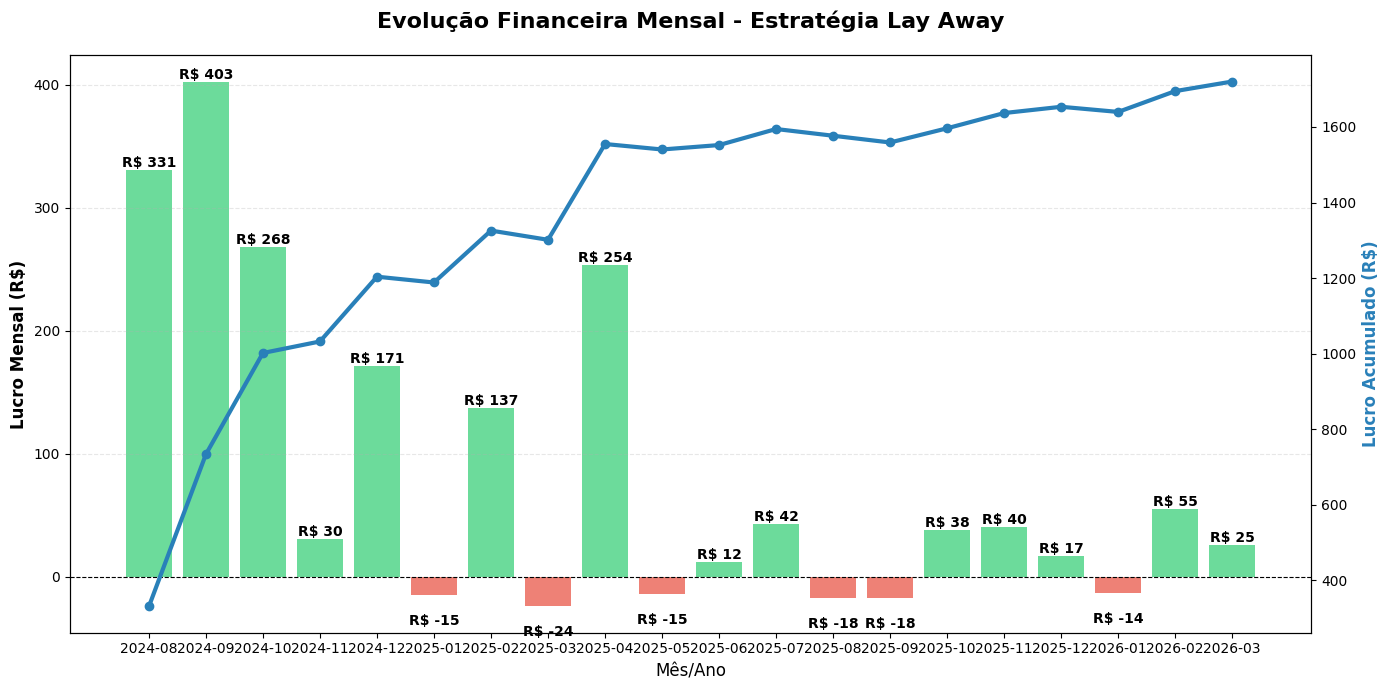

In [13]:
# --- 1. Preparação dos Dados para o Gráfico ---
eixo_x = resumo.index.astype(str)
lucro_mensal_valores = lucro_por_mes.values
lucro_acum_valores = lucro_acumulado.values

# --- 2. Criação do Gráfico de Evolução ---
fig, ax1 = plt.subplots(figsize=(14, 7))

# Gráfico de Barras: Lucro Mensal (Eixo Esquerdo)
cores = ['#2ecc71' if x > 0 else '#e74c3c' for x in lucro_mensal_valores]
bars = ax1.bar(eixo_x, lucro_mensal_valores, color=cores, alpha=0.7, label='Lucro Mensal (R$)')
ax1.set_ylabel('Lucro Mensal (R$)', fontsize=12, fontweight='bold')
ax1.set_xlabel('Mês/Ano', fontsize=12)
ax1.axhline(0, color='black', linewidth=0.8, linestyle='--')

# Eixo Secundário para o Lucro Acumulado (Linha)
ax2 = ax1.twinx()
ax2.plot(eixo_x, lucro_acum_valores, color='#2980b9', marker='o', linewidth=3, label='Lucro Acumulado (R$)')
ax2.set_ylabel('Lucro Acumulado (R$)', fontsize=12, fontweight='bold', color='#2980b9')

# Ajustes de Layout
plt.title('Evolução Financeira Mensal - Estratégia Lay Away', fontsize=16, fontweight='bold', pad=20)
ax1.grid(axis='y', linestyle='--', alpha=0.3)

# Adicionando rótulos de valores nas barras
for bar in bars:
    yval = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, yval if yval > 0 else yval-15,
             f'R$ {yval:.0f}', ha='center', va='bottom' if yval > 0 else 'top', fontsize=10, fontweight='bold')

fig.tight_layout()
plt.show()

# **9. Simulação de Monte Carlo**

In [14]:
# ==============================================================
# SIMULAÇÃO DE MONTE CARLO (TESTE DE ESTRESSE DE BANCA)
# ==============================================================

# 1. Configurações da Simulação
simulacoes = 10000        # Quantidade de "vidas" testadas
entradas_por_sim = 1000    # Horizonte de tempo (1000 jogos)
banca_inicial = 1500
responsabilidade = 30      # Valor arriscado por entrada (Stake)

# 2. Estatísticas Extraídas do Modelo (Garantindo que existam)
if 'df' in locals() and len(df) > 0:
    P_win = (df['Result'] != 'A').sum() / len(df)
    P_loss = 1 - P_win

    # Ganhos e Perdas Médios reais do seu histórico
    G = df[df['Profit'] > 0]['Profit'].mean() if len(df[df['Profit'] > 0]) > 0 else 0
    L = abs(df[df['Profit'] < 0]['Profit'].mean()) if len(df[df['Profit'] < 0]) > 0 else responsabilidade

    ruinas = 0

    # 3. Loop de Simulação
    for _ in range(simulacoes):
        banca = banca_inicial
        # Geramos todos os resultados de uma vez para ganhar velocidade
        resultados = np.random.choice([G, -L], size=entradas_por_sim, p=[P_win, P_loss])

        # Simulamos a caminhada do saldo
        saldo_ao_longo_do_tempo = banca + np.cumsum(resultados)

        # Se em algum momento o saldo for <= 0, contamos como ruína
        if np.any(saldo_ao_longo_do_tempo <= 0):
            ruinas += 1

    risco_ruina_mc = (ruinas / simulacoes) * 100

    print("-" * 40)
    print(f"🎯 ESTATÍSTICAS PARA MONTE CARLO")
    print(f"Prob. de Win: {P_win:.2%} | Payoff (G/L): {G/L:.2f}")
    print(f"Risco de Ruína (Monte Carlo): {risco_ruina_mc:.2f}%")
    print("-" * 40)
else:
    print("⚠️ Dados insuficientes para rodar Monte Carlo.")

----------------------------------------
🎯 ESTATÍSTICAS PARA MONTE CARLO
Prob. de Win: 76.53% | Payoff (G/L): 0.42
Risco de Ruína (Monte Carlo): 0.00%
----------------------------------------


# **10. Gráfico das Simulações de Monte Carlo**

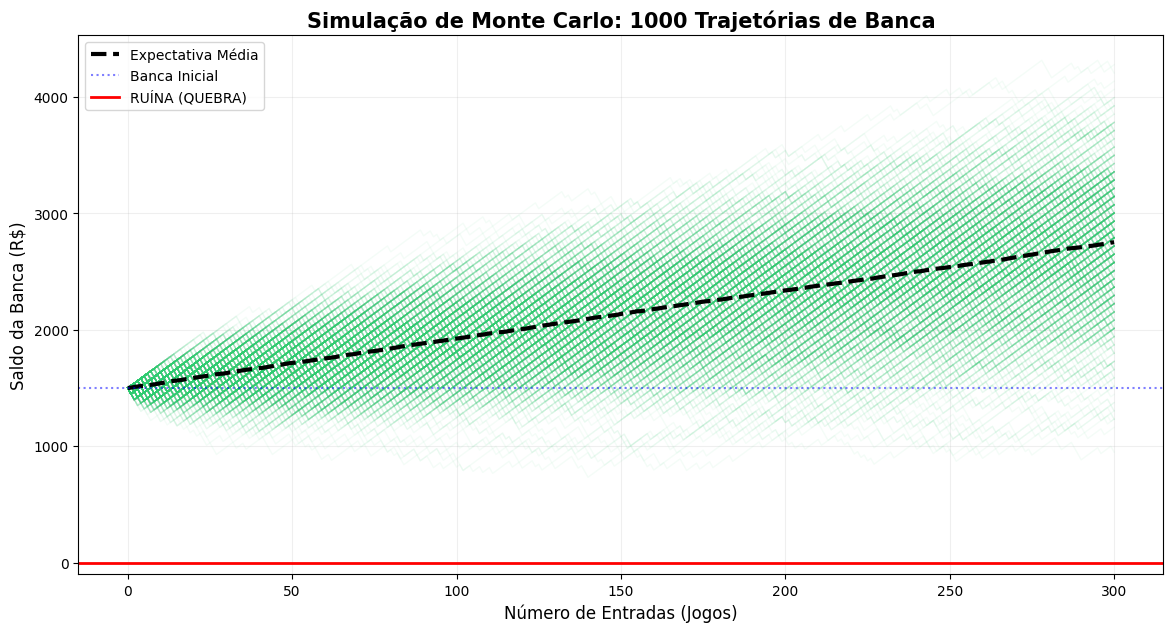

In [15]:
# ==============================================================
# VISUALIZAÇÃO DE CAMINHOS ALEATÓRIOS (MONTE CARLO)
# ==============================================================
import matplotlib.pyplot as plt

# 1. Parâmetros de Visualização
simulacoes_plot = 1000   # Reduzi para 1000 para manter a fluidez do gráfico
entradas_por_sim = 300   # Foco no curto/médio prazo (aprox. 1 a 2 meses de entradas)
evolucoes = []

np.random.seed(42)

# 2. Execução das Simulações
for _ in range(simulacoes_plot):
    banca = banca_inicial
    historico = [banca]
    # Geramos os resultados do cenário de uma vez (vetorizado para performance)
    passos = np.random.choice([G, -L], size=entradas_por_sim, p=[P_win, P_loss])
    caminho = banca + np.cumsum(passos)
    evolucoes.append(np.insert(caminho, 0, banca)) # Inclui a banca inicial no começo

# 3. Plotagem Profissional
plt.figure(figsize=(14, 7))

# Plotar as linhas individuais com alta transparência
for i, simulacao in enumerate(evolucoes):
    # Pintamos de vermelho as simulações que tocaram o zero (Quebra)
    cor = 'red' if np.any(simulacao <= 0) else '#2ecc71'
    plt.plot(simulacao, color=cor, alpha=0.05, linewidth=1)

# Linha da Média (Expectativa Matemática Real)
media_evolucao = np.mean(evolucoes, axis=0)
plt.plot(media_evolucao, color='black', linewidth=3, label='Expectativa Média', linestyle='--')

# Estilização
plt.title(f'Simulação de Monte Carlo: {simulacoes_plot} Trajetórias de Banca', fontsize=15, fontweight='bold')
plt.xlabel('Número de Entradas (Jogos)', fontsize=12)
plt.ylabel('Saldo da Banca (R$)', fontsize=12)
plt.axhline(banca_inicial, color='blue', linestyle=':', alpha=0.5, label='Banca Inicial')
plt.axhline(0, color='red', linestyle='-', linewidth=2, label='RUÍNA (QUEBRA)')

plt.grid(True, alpha=0.2)
plt.legend(loc='upper left')

# Limitar o eixo Y para não dispersar demais se houver outliers
plt.ylim(bottom=-100)

plt.show()

# --- ANÁLISE DO GRÁFICO ---
# - Linhas Verdes (Alpha 0.05): Sucesso.
# - Linhas Vermelhas: Caminhos que levaram à falência.
# - Linha Preta Tracejada: Onde você provavelmente estará após 300 jogos.